# Chapter 5. 내비게이션 데이터를 기반 EDA 실습


## 목적: 내비게이션 분석하고 교통 패턴을 파악하여 비즈니스 인사이트 도출

###📊 학습 목표:
-  실제 비즈니스 데이터와 유사한 내비게이션 데이터로 EDA 수행
-  교통 패턴을 파악하여 비즈니스 인사이트 도출
-  데이터 분석의 체계적인 접근 방법 학습


# 1.환경 설정
## 1.1 라이브러리 import



In [42]:
# 기본 데이터 처리
import pandas as pd
import numpy as np

# 시각화
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm

# 경고 메시지 제거
import warnings
warnings.filterwarnings('ignore')

# 시각화 스타일 설정
sns.set_style("whitegrid")
plt.style.use('default')

# Google Colab 과 Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


###💡 핵심 개념: 라이브러리의 역할

- pandas: 엑셀과 같은 표 형태 데이터 처리의 핵심 도구
- matplotlib/seaborn: 그래프 그리기 도구 (seaborn이 더 예쁜 그래프)
- numpy: 수학 계산을 빠르게 처리

In [58]:
# [옵션]
# 경고 메시지 및 스타일 설정
import warnings
warnings.filterwarnings('ignore')  # 불필요한 경고 메시지 숨기기

# Google Colab 환경에서 한글 폰트 설정
## 목적: 그래프에서 한글이 깨지지 않도록 설정
try:
    # Colab 환경에서 한글 폰트 설치
    !sudo apt-get install -y fonts-nanum
    !sudo fc-cache -fv
    !rm ~/.cache/matplotlib -rf

    import matplotlib.font_manager as fm
    fontpath = '/usr/share/fonts/truetype/nanum/NanumGothicCoding.ttf'
    font = fm.FontProperties(fname=fontpath, size=10)
    plt.rcParams['font.family'] = 'NanumGothicCoding'
    plt.rcParams['axes.unicode_minus'] = False
    print("✅ 한글 폰트 설정 완료")
except:
    # 로컬 환경이나 폰트 설치 실패시 기본 설정
    plt.rcParams['font.family'] = 'DejaVu Sans'
    plt.rcParams['axes.unicode_minus'] = False
    print("⚠️ 기본 폰트로 설정됨")

# 시각화 스타일 설정
sns.set_style("whitegrid")      # seaborn 스타일 적용
plt.style.use('default')        # matplotlib 기본 스타일

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-nanum is already the newest version (20200506-1).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/

In [4]:
# import matplotlib.pyplot as plt
# import matplotlib.font_manager as fm
# plt.rc('font', family='NanumGothicCoding')

In [5]:
# !sudo apt-get install -y fonts-nanum
# !sudo fc-cache -fv
# !rm ~/.cache/matplotlib -rf

# 2. 데이터 불러오기 및 기본 확인
## 2.1 데이터 로드

In [44]:
# 데이터 불러오기 및 데이터 확인
df_base = pd.read_json('/content/drive/MyDrive/AICE_Association/onenavi/A0007IT.json')
df_base.head()

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day
0,router-84875df7fc-cmkz9-2-9617301-0,19:43:56,19:56:38.537000,3246.0,762.653992,15.322283,경기도,평택시,0,19,27
1,router-84875df7fc-scxcj-6-13366366-0,12:23:05,12:36:32.620000,3858.0,796.081970,17.446445,경기도,의정부시,4,12,24
2,router-84875df7fc-52vz8-6-62202063-0,19:10:35,19:29:07.306000,4125.0,1112.468018,13.348698,경기도,광명시,0,19,27
3,router-84875df7fc-8n4sw-5-6914479-0,11:59:58,12:10:55.999000,3748.0,651.973022,20.695335,경기도,안산시 상록구,0,11,20
4,router-84875df7fc-8n4sw-7-75115963-0,15:16:53,15:26:52.222000,3153.0,597.419006,18.999730,경기도,성남시 중원구,2,15,29


### [참고] 데이터 컬럼 설명

- RID                 : 경로ID (각 운행의 고유 번호)
- Time_Departure      : 출발시각
- Time_Arrival        : 도착시각
- Distance            : 이동 거리, 단위 (m)
- Time_Driving        : 실주행시간(초)
- Speed_Per_Hour      : 평균시속
- Address1            : 주소1
- Address2            : 주소2
- Weekday             : Time_Departure(출발시각)의 요일
- Hour                : Time_Departure(출발시각)의 시각
- Day                 : Time_Departure(출발시각)의 날짜


# 2.2 데이터 구조파악및 품질평가

1.   데이터가 잘 들어왔나? (짤리거나 밀리지는 않았나?) → .head(),.tail()
2.   데이터 형태는 어떤 형태인가? → .shape
3.   데이터 어떤 변수가 있나? → .columns
4.   각 변수의 타입은 어떤한가? → .dtypes
5.   각 변수에 NULL 값이 있나? → .isnull().sum()
6.   단계가 너무 많은데 한번에 볼수 없나?  → .info()

In [7]:
# 데이터가 짤리거나 밀리지 않았나?
df_base.tail()

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day
9995,router-84875df7fc-scxcj-7-54933587-0,05:38:47,05:51:42.160000,10807.0,774.018982,50.263884,경기도,평택시,3,5,23
9996,router-84875df7fc-scxcj-7-68273662-0,16:08:39,16:33:52.275000,6270.0,1511.703003,14.931504,서울특별시,서초구,1,16,28
9997,router-84875df7fc-b5nxc-5-8232889-0,08:25:22,08:40:26.182000,10484.0,890.312988,42.392283,경기도,안산시 단원구,1,8,21
9998,router-84875df7fc-52vz8-6-53906748-0,06:49:59,06:55:01.087000,6529.0,300.302002,78.269208,경기도,성남시 분당구,4,6,24
9999,router-84875df7fc-scxcj-3-24830357-0,23:09:24,23:25:32.432000,7976.0,969.362000,29.621132,서울특별시,마포구,4,23,24


In [8]:
df_base.isnull().sum().sum()

np.int64(2)

In [53]:
# 데이터 형태 확인
print("데이터 크기:", df_base.shape)
print("\n" + "=" * 50)

# Column명 확인
print("컬럼명:", df_base.columns.tolist())
print("\n" + "=" * 50)

# 데이터 타입 확인
print("데이터 타입:\n", df_base.dtypes)
print("\n" + "=" * 50)

# NULL 값 확인
print("결측값 개수:", df_base.isnull().sum().sum())
print("\n" + "=" * 50)

데이터 크기: (10000, 11)

컬럼명: ['RID', 'Time_Departure', 'Time_Arrival', 'Distance', 'Time_Driving', 'Speed_Per_Hour', 'Address1', 'Address2', 'Weekday', 'Hour', 'Day']

데이터 타입:
 RID                object
Time_Departure     object
Time_Arrival       object
Distance          float64
Time_Driving      float64
Speed_Per_Hour    float64
Address1           object
Address2           object
Weekday             int64
Hour                int64
Day                 int64
dtype: object

결측값 개수: 2



In [54]:
df_base.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RID             10000 non-null  object 
 1   Time_Departure  10000 non-null  object 
 2   Time_Arrival    10000 non-null  object 
 3   Distance        9998 non-null   float64
 4   Time_Driving    10000 non-null  float64
 5   Speed_Per_Hour  10000 non-null  float64
 6   Address1        10000 non-null  object 
 7   Address2        10000 non-null  object 
 8   Weekday         10000 non-null  int64  
 9   Hour            10000 non-null  int64  
 10  Day             10000 non-null  int64  
dtypes: float64(3), int64(3), object(5)
memory usage: 937.5+ KB


In [40]:
# 기초 데이터 종합 확인
print(df_base.info())

<class 'pandas.core.frame.DataFrame'>
Index: 10000 entries, 0 to 9999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   RID             10000 non-null  object 
 1   Time_Departure  10000 non-null  object 
 2   Time_Arrival    10000 non-null  object 
 3   Distance        9998 non-null   float64
 4   Time_Driving    10000 non-null  float64
 5   Speed_Per_Hour  10000 non-null  float64
 6   Address1        10000 non-null  object 
 7   Address2        10000 non-null  object 
 8   Weekday         10000 non-null  int64  
 9   Hour            10000 non-null  int64  
 10  Day             10000 non-null  int64  
 11  rush_hour_yn    10000 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 1015.6+ KB
None


###💡 핵심 개념: 데이터 탐색의 기본 단계

- 크기 확인: 몇 개의 행과 열이 있는지
- 타입 확인: 숫자형/문자형 구분
- 결측값 확인: 비어있는 데이터가 있는지
- 샘플 확인: 실제 데이터가 어떻게 생겼는지
---

# 3. 단변수 분석 (Univariate Analysis)
1.   변수별 간단한 기초통계 확인 → .describe()
2.   범주형 변수 빈도확인 → .value_counts()
3.   시각화 (히스토그램, 상자도표, 막대도표, 파이차트)

### 3.1 숫자형 변수 기초 통계

In [62]:
# 기초 통계량 확인
df_base.describe()

,Distance,Time_Driving,Speed_Per_Hour,Weekday,Hour,Day
count,9998.000000,10000.000000,10000.000000,10000.000000,10000.0000,10000.000000
mean,7023.846169,967.863379,29.470554,2.025800,12.9548,25.507600
std,3257.850403,498.632830,14.263985,1.353557,4.7358,3.404659
min,3000.000000,129.272995,3.432213,0.000000,0.0000,20.000000
25%,4273.250000,601.422760,19.690803,1.000000,9.0000,23.000000
50%,6121.000000,880.683990,26.259856,2.000000,13.0000,24.000000
75%,9257.750000,1200.376007,35.811288,3.000000,17.0000,29.000000
max,15000.000000,5010.689025,305.179227,4.000000,23.0000,31.000000


###💡 핵심 개념: describe()로 알 수 있는 것들

- count: 데이터 개수
- mean: 평균 (전체의 중심값)
- std: 표준편차 (데이터가 얼마나 흩어져 있는지)
- min/max: 최솟값/최댓값
- 25%/50%/75%: 1사분위/중앙값/3사분위

## 3.2 범주형 변수 분포 확인

In [64]:
# 요일별 데이터 개수
print("요일별 데이터 분포:")
df_base['Weekday'].value_counts().sort_index()

요일별 데이터 분포:


,count
Weekday,
0,1766
1,2064
2,1988
3,2510
4,1672


In [14]:
# 범주형 변수 분포 확인 : 주소
print("\n지역별 데이터 분포:")
print(df_base['Address1'].value_counts())


지역별 데이터 분포:
Address1
경기도      6014
서울특별시    3956
인천광역시      27
-           3
Name: count, dtype: int64


## 3.3 단변수 시각화
###히스토그램 (연속형 변수)

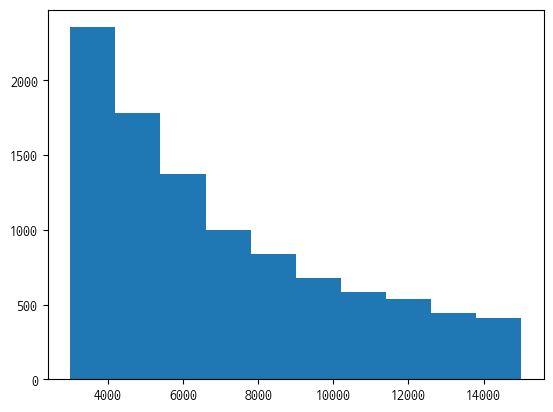

In [68]:
# 시각화 1: 단변수 시각화
plt.figure()
plt.hist(df_base['Distance'],bins = 10)
plt.show()

<Axes: xlabel='Distance', ylabel='Count'>

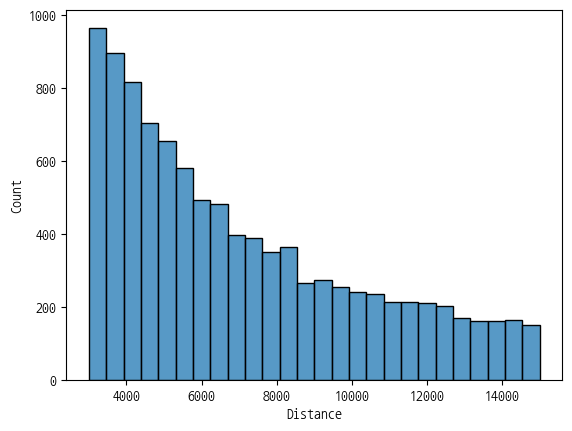

In [69]:
# seaborn 을 이용한 빠른 시각화
sns.histplot(df_base['Distance'],bins = 25)

In [60]:
# 한글 폰트 설정 (선택사항)
plt.rcParams['font.family'] = 'NanumGothicCoding'
plt.rcParams['axes.unicode_minus'] = False

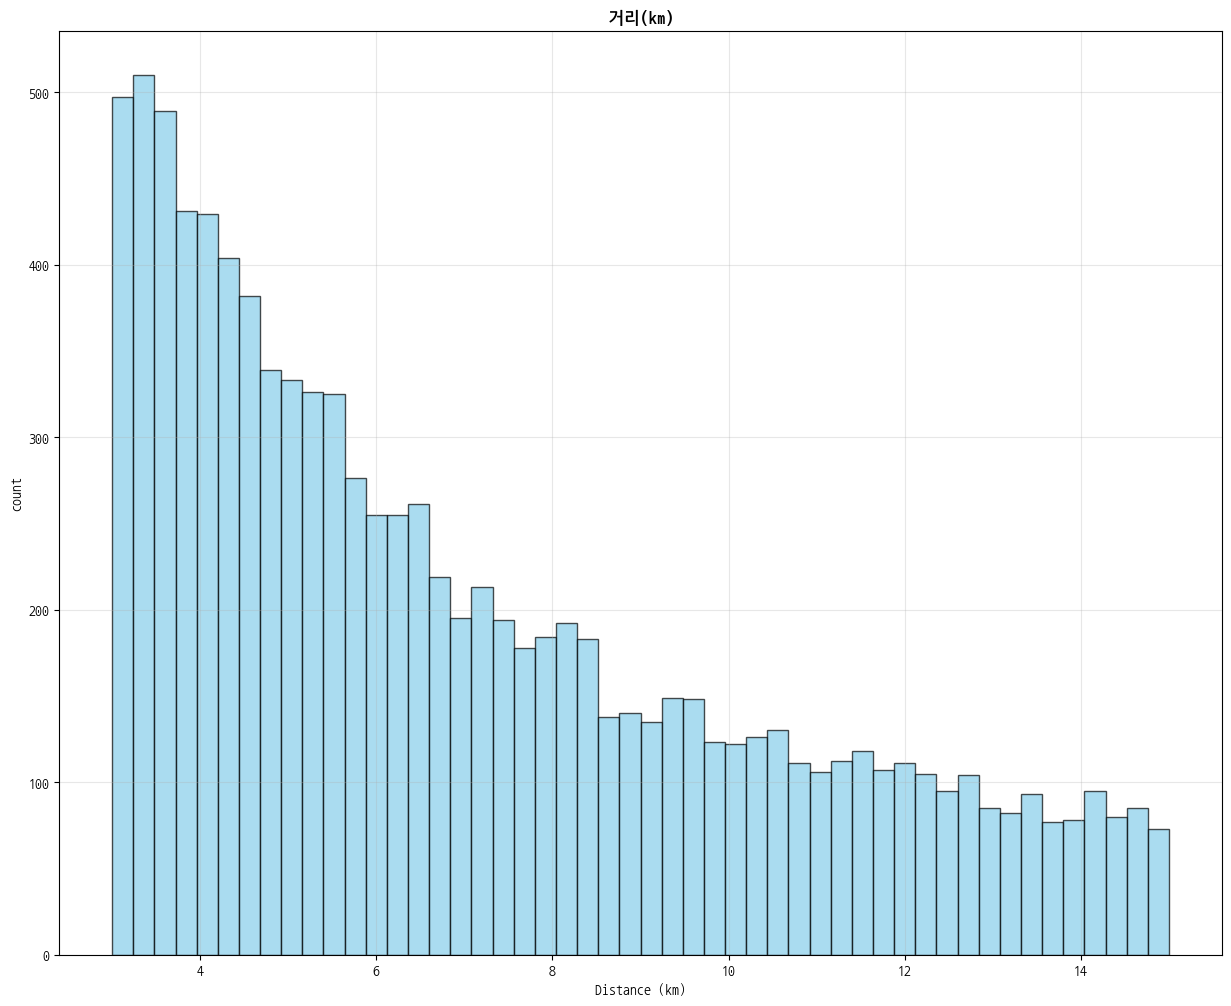

In [70]:
# 시각화 "거리" 분포 추가 옵션 설정
plt.figure(figsize=(15, 12))

plt.hist(df_base['Distance']/1000, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
plt.title('거리(km)', fontsize=12, fontweight='bold')
plt.xlabel('Distance (km)')
plt.ylabel('count')
plt.grid(alpha=0.3)

### 막대그래프 (범주형 변수)

In [19]:
weekday_counts= df_base['Weekday'].value_counts().sort_index()
weekday_counts

,count
Weekday,
0,1766
1,2064
2,1988
3,2510
4,1672


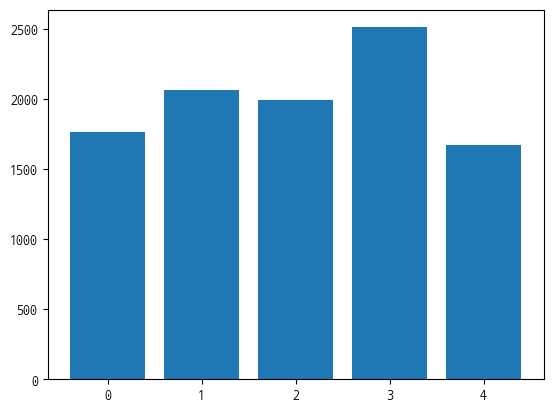

In [20]:
weekday_counts = df_base['Weekday'].value_counts().sort_index()
# print(weekday_counts)

plt.figure()
plt.bar(weekday_counts.index,weekday_counts)
plt.show()

<Axes: xlabel='Weekday'>

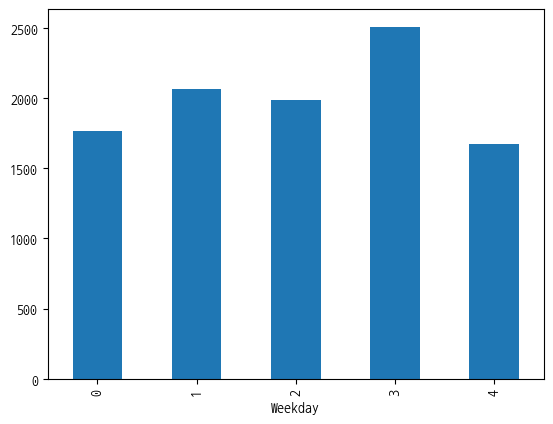

In [76]:
# seabron 을 이용한 빠른 시각화
df_base['Weekday'].value_counts().sort_index().plot(kind='bar')

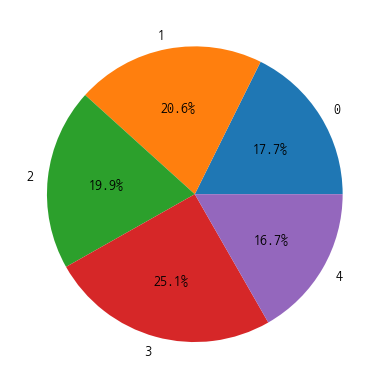

In [78]:
plt.figure()
plt.pie(weekday_counts, labels=weekday_counts.index, autopct='%1.1f%%')
plt.show()

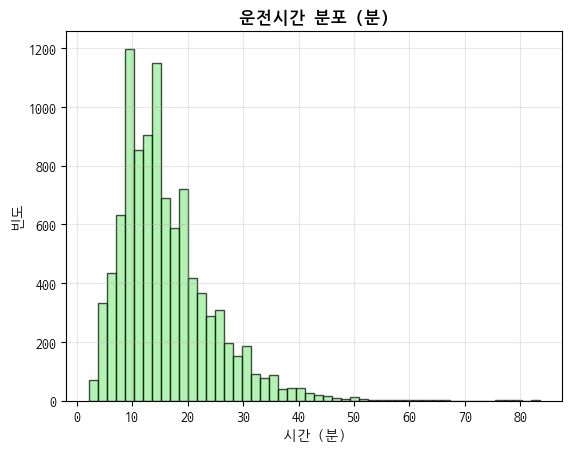

In [23]:
plt.hist(df_base['Time_Driving']/60, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('운전시간 분포 (분)', fontsize=12, fontweight='bold')
plt.xlabel('시간 (분)')
plt.ylabel('빈도')
plt.grid(alpha=0.3)

### 상자도표 (이상값 확인)

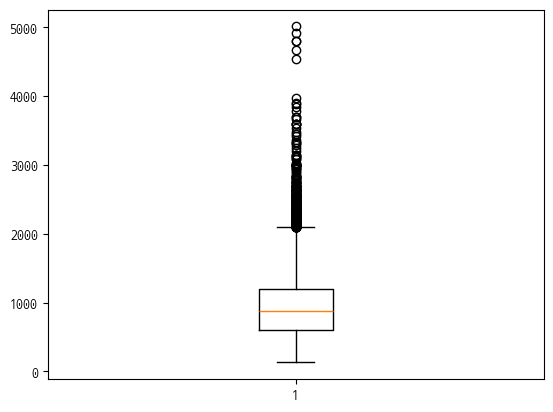

In [25]:
# 상자도표
plt.figure()
plt.boxplot(df_base['Time_Driving'])
plt.show()

###💡 핵심 개념: 시각화의 목적

- 히스토그램: 데이터의 분포 모양 확인 (정규분포인지, 치우쳐있는지)
- 막대그래프: 범주별 빈도 비교
- 상자그림: 이상값(outlier) 발견, 데이터의 분포 요약

## 4. 변수간 관계 분석 (Bivariate Analysis)

 ### 4.1 (두변수간) 상관관계 분석

In [26]:
df_base[['Distance','Time_Driving']].corr()

,Distance,Time_Driving
Distance,1.000000,0.540637
Time_Driving,0.540637,1.000000


In [27]:
# 거리와 시간간의 상관관계 r 값 구하기
df_base[['Distance', 'Time_Driving']].corr()
# df_base['Distance'].corr(df_base['Time_Driving'])

,Distance,Time_Driving
Distance,1.000000,0.540637
Time_Driving,0.540637,1.000000


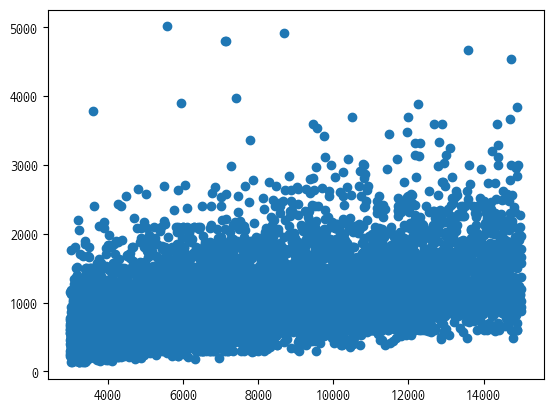

In [28]:
# 거리와 시간간의 상관관계를 산점도로 시각화
plt.figure()
plt.scatter(df_base['Distance'], df_base['Time_Driving'])
plt.show()

 ### 4.2 (다변수간) 상관관계 분석

In [84]:
# 전체 상관관계를 히트맵으로 그리기
correlation_matrix = df_base[['Distance', 'Time_Driving', 'Speed_Per_Hour']].corr()

print("상관관계 매트릭스:")
correlation_matrix

상관관계 매트릭스:


,Distance,Time_Driving,Speed_Per_Hour
Distance,1.000000,0.540637,0.334128
Time_Driving,0.540637,1.000000,-0.433429
Speed_Per_Hour,0.334128,-0.433429,1.000000


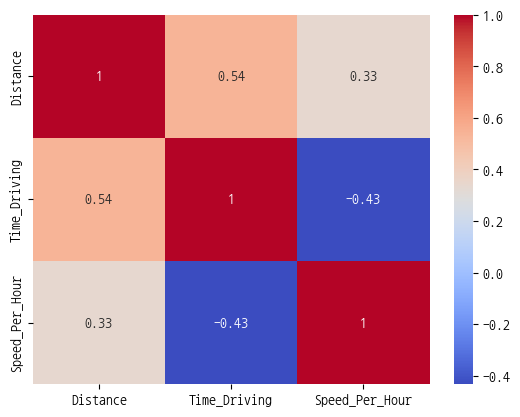

In [86]:
#df_corr 데이터로 히트맵 그리기
plt.figure()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.show()

### 💡 핵심 개념: 상관관계 해석

- 0.7 이상: 강한 양의 상관관계 (한 변수가 증가하면 다른 변수도 증가)
- -0.7 이하: 강한 음의 상관관계 (한 변수가 증가하면 다른 변수는 감소)
- -0.3 ~ 0.3: 약한 상관관계
- 상관관계 ≠ 인과관계: 상관관계가 있다고 해서 반드시 원인-결과 관계는 아님

## 5. EDA (비즈니스 인사이트 도출을 위한 질문 )
1.   평균속도는 몇이고  평균 속도보다 늦은 시간대는 몇시 부터 몇시 까지일까?
2.   러시아워 (출근 : 6시 - 8시, 퇴근 : 19시 - 21시)가 다른시간 시간대에 비해 느리다고 할 수 있나?

### 5.1 시간대별 교통 패턴 분석

In [87]:
df_base['Speed_Per_Hour'].mean()

np.float64(29.47055441272721)

In [32]:
# 시간대별 평균 속도 계산
df_base.groupby('Hour')['Speed_Per_Hour'].mean()

,Speed_Per_Hour
Hour,
0,37.477312
1,37.894207
2,45.205265
3,44.066389
4,42.056995
5,40.858630
6,36.165774
7,27.302927
8,26.284367


<Axes: xlabel='Hour'>

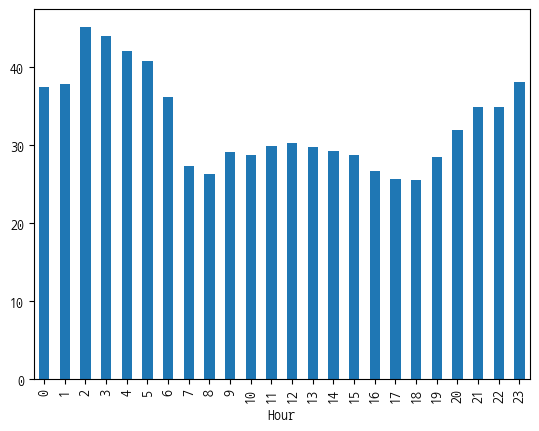

In [89]:
# 시간대별 평균 속도 시각화
df_base.groupby('Hour')['Speed_Per_Hour'].mean().plot(kind='bar')

### 5.2 러시아워 분석

In [90]:
# 러시아워 정의 (출근: 7-9시, 퇴근: 18-20시)
df_base['rush_hour_yn'] = df_base['Hour'].apply(
    lambda x: 1 if 6 <= x <= 8 or 19 <= x <= 21 else 0)
df_base.head()

,RID,Time_Departure,Time_Arrival,Distance,Time_Driving,Speed_Per_Hour,Address1,Address2,Weekday,Hour,Day,rush_hour_yn
0,router-84875df7fc-cmkz9-2-9617301-0,19:43:56,19:56:38.537000,3246.0,762.653992,15.322283,경기도,평택시,0,19,27,1
1,router-84875df7fc-scxcj-6-13366366-0,12:23:05,12:36:32.620000,3858.0,796.081970,17.446445,경기도,의정부시,4,12,24,0
2,router-84875df7fc-52vz8-6-62202063-0,19:10:35,19:29:07.306000,4125.0,1112.468018,13.348698,경기도,광명시,0,19,27,1
3,router-84875df7fc-8n4sw-5-6914479-0,11:59:58,12:10:55.999000,3748.0,651.973022,20.695335,경기도,안산시 상록구,0,11,20,0
4,router-84875df7fc-8n4sw-7-75115963-0,15:16:53,15:26:52.222000,3153.0,597.419006,18.999730,경기도,성남시 중원구,2,15,29,0


In [91]:
# 러시아워 vs 비러시아워 속도 비교
print("전체 평균 속도:")
print(df_base['Speed_Per_Hour'].mean())
print("\n" + "=" * 50)

print("러시아워 속도 비교:")
df_base.groupby('rush_hour_yn')['Speed_Per_Hour'].mean()

전체 평균 속도:
29.47055441272721

러시아워 속도 비교:


,Speed_Per_Hour
rush_hour_yn,
0,29.376824
1,29.751296


In [92]:
rush_comparison = df_base.groupby('rush_hour_yn')['Speed_Per_Hour'].agg(['mean', 'std'])
rush_comparison

,mean,std
rush_hour_yn,,
0,29.376824,14.287342
1,29.751296,14.192939


### 5.3 요일별 패턴 분석

In [38]:
# 요일별 평균과 표준편차
pd.concat([df_base.groupby('Weekday')['Speed_Per_Hour'].mean(),
          df_base.groupby('Weekday')['Speed_Per_Hour'].std()],axis=1)

,Speed_Per_Hour,Speed_Per_Hour
Weekday,,
0,29.545284,13.914322
1,29.636632,14.996005
2,28.767496,14.003728
3,29.055191,13.740780
4,30.646083,14.710217


<Axes: xlabel='Speed_Per_Hour', ylabel='Density'>

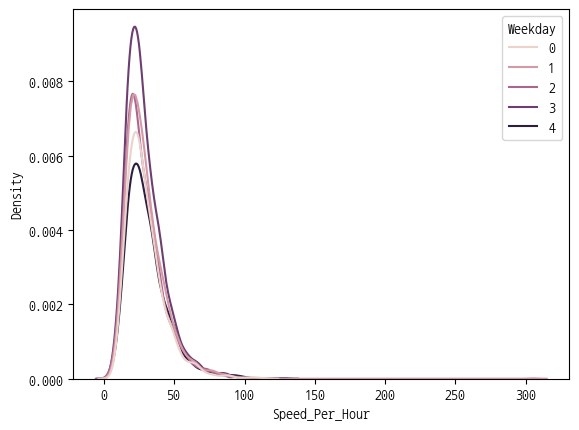

In [39]:
# 요일별 평균속도의 밀도그래프
sns.kdeplot(data=df_base, x='Speed_Per_Hour', hue='Weekday')

### 💡 핵심 개념: 비즈니스 인사이트란?

- 패턴 발견: 데이터에서 의미있는 규칙성 찾기
- 가설 검증: "러시아워에 속도가 느릴 것이다" 같은 가설을 데이터로 확인
- 의사결정 지원: 분석 결과를 바탕으로 실제 비즈니스 결정에 도움

# 6. 결론

1. 러시아워 효과: 7-9시, 19-21시에 평균 속도가 현저히 감소하기 보다는 9~18 시까지 업무시간대 속도가 감소한다.
2. 요일별 차이: 주중 요일별 속도차이 크지 않다.
3. 거리-시간 관계: 거리와 주행시간은 강한 양의 상관관계 (r=0.54)


###💡 기억할 점
EDA는 **탐정 놀이**와 같습니다. 데이터 속에 숨어있는 스토리를 찾아내는 과정이며, 이를 통해 실제 비즈니스 가치를 창출할 수 있습니다!